In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


In [3]:
def true_vdp_dynamics(x, mu=1.0):
    """
    Van der Pol oscillator dynamics:
        dx1/dt = x2
        dx2/dt = mu * (1 - x1^2) * x2 - x1
    x shape: (batch_size, 2)
    return
        dx/dt shape: (batch_size, 2)
    """

    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    dx1dt = x2
    dx2dt = mu * (1 - x1**2) * x2 - x1

    dxdt = torch.cat([dx1dt, dx2dt], dim=1)
    return dxdt



In [4]:
def rk4_step_true_vdp(x, dt, mu=1.0):

    k1 = true_vdp_dynamics(x, mu)
    k2 = true_vdp_dynamics(x + 0.5 * dt * k1, mu)
    k3 = true_vdp_dynamics(x + 0.5 * dt * k2, mu)
    k4 = true_vdp_dynamics(x + dt * k3, mu)

    x_next = x + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)
    return x_next



In [5]:
class VanDerPolDataset(Dataset):
    def __init__(
        self,
        n_traj=200,
        n_steps=400,
        T=20.0,
        mu=1.0,
        x0_min=-3.0,
        x0_max=3.0,
        seed=42
    ):
        """
        Dataset for Van der Pol oscillator:

            dx1/dt = x2
            dx2/dt = mu * (1 - x1^2) * x2 - x1

        Each sample:
            x0: shape [2]
            x:  shape [n_steps, 2]
        """

        self.n_traj = n_traj
        self.n_steps = n_steps
        self.T = T
        self.mu = mu

        generator = torch.Generator().manual_seed(seed)

        # Time vector
        self.t = torch.linspace(0.0, T, n_steps)

        # Different initial conditions 
        self.x0 = torch.empty(n_traj, 2).uniform_(
            x0_min, x0_max, generator=generator
        )

        # Generate true trajectory 
        self.x = self._simulate_trajectories()

    def _simulate_trajectories(self):
        xs = [self.x0]
        x = self.x0

        for k in range(self.n_steps - 1):
            dt = self.t[k + 1] - self.t[k]
            x = rk4_step_true_vdp(x, dt, mu=self.mu)
            xs.append(x)

        # shape [n_traj, n_steps, 2]
        return torch.stack(xs, dim=1)

    def __len__(self):
        return self.n_traj

    def __getitem__(self, idx):
        return {
            "x0": self.x0[idx],   # [2]
            "x": self.x[idx]      # [n_steps, 2]
        }
    
    

In [6]:
dataset = VanDerPolDataset(
    n_traj=100,
    n_steps=200,
    T=10.0,
    mu=1.0
)

sample = dataset[0]

print("Number of trajectories:", len(dataset))
print("t shape:", dataset.t.shape)
print("x0 shape:", sample["x0"].shape)
print("x trajectory shape:", sample["x"].shape)

Number of trajectories: 100
t shape: torch.Size([200])
x0 shape: torch.Size([2])
x trajectory shape: torch.Size([200, 2])


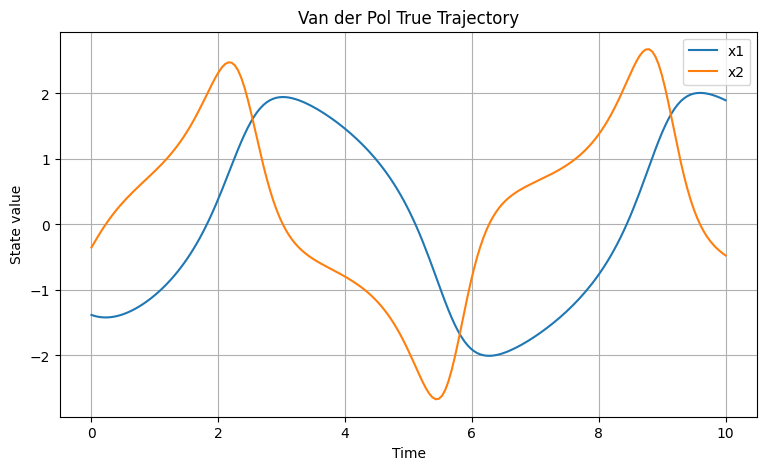

In [7]:
idx = 10
sample = dataset[idx]
t = dataset.t

plt.figure(figsize=(9, 5))
plt.plot(t.numpy(), sample["x"][:, 0].numpy(), label="x1")
plt.plot(t.numpy(), sample["x"][:, 1].numpy(), label="x2")
plt.xlabel("Time")
plt.ylabel("State value")
plt.title("Van der Pol True Trajectory")
plt.legend()
plt.grid(True)
plt.show()

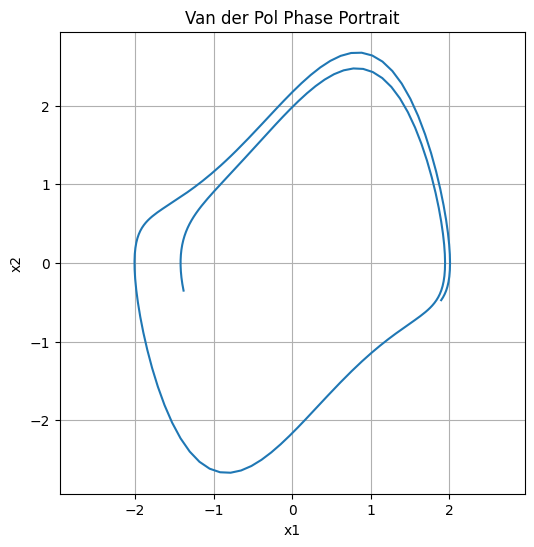

In [8]:
plt.figure(figsize=(6, 6))
plt.plot(sample["x"][:, 0].numpy(), sample["x"][:, 1].numpy())
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Van der Pol Phase Portrait")
plt.grid(True)
plt.axis("equal")
plt.show()

In [9]:
class VanDerPolNODEFunc(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        """
        x shape: [batch_size, 2]

        return:
            dxdt shape: [batch_size, 2]
        """

        dxdt = self.net(x)
        return dxdt

In [10]:
def rk4_solve_node(func, x0, t):
    """
    Use NODE function to generate predicted trajectory.

    func: NODE model learned dx/dt = f_theta(x)
    x0: shape [batch_size, 2]
    t: shape [n_steps]

    return:
        xs shape [batch_size, n_steps, 2]
    """

    xs = [x0]
    x = x0

    for k in range(len(t) - 1):
        dt = t[k + 1] - t[k]

        k1 = func(x)
        k2 = func(x + 0.5 * dt * k1)
        k3 = func(x + 0.5 * dt * k2)
        k4 = func(x + dt * k3)

        x = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

        xs.append(x)

    return torch.stack(xs, dim=1)

In [11]:
dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

t = dataset.t.to(device)

func = VanDerPolNODEFunc().to(device)

optimizer = torch.optim.Adam(func.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

n_epochs = 1000

for epoch in range(n_epochs):
    total_loss = 0.0

    for batch in dataloader:
        x0_batch = batch["x0"].to(device)   # [batch_size, 2]
        true_x = batch["x"].to(device)      # [batch_size, n_steps, 2]

        optimizer.zero_grad()
    
        pred_x = rk4_solve_node(
            func=func,
            x0=x0_batch,
            t=t
        )

        loss = loss_fn(pred_x, true_x)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss = {avg_loss:.8f}")

Epoch    0 | Loss = 6.45154381
Epoch  100 | Loss = 0.57732314
Epoch  200 | Loss = 0.41974741
Epoch  300 | Loss = 0.30379385
Epoch  400 | Loss = 0.16472706
Epoch  500 | Loss = 0.08488237
Epoch  600 | Loss = 0.05024699
Epoch  700 | Loss = 0.04245393
Epoch  800 | Loss = 0.02832140
Epoch  900 | Loss = 0.02275119


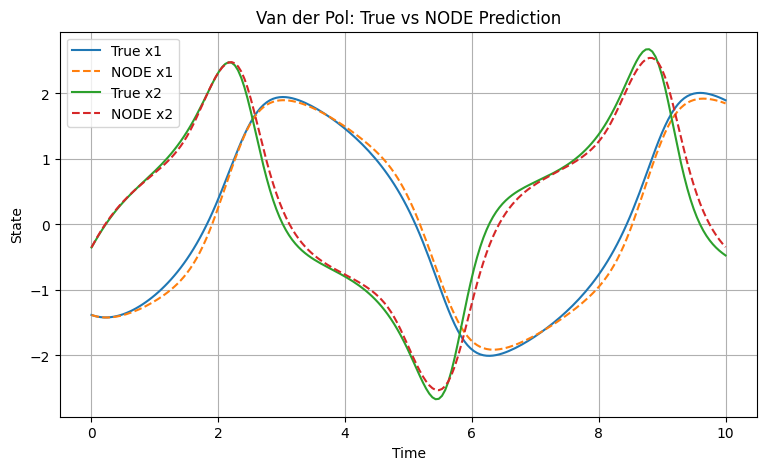

In [12]:
func.eval()

idx = 10

with torch.no_grad():
    sample = dataset[idx]

    x0_test = sample["x0"].unsqueeze(0).to(device)   # [1, 2]
    true_x = sample["x"].unsqueeze(0).to(device)     # [1, n_steps, 2]

    pred_x = rk4_solve_node(
        func=func,
        x0=x0_test,
        t=t
    )

true_x_cpu = true_x.cpu()
pred_x_cpu = pred_x.cpu()
t_cpu = t.cpu()

plt.figure(figsize=(9, 5))
plt.plot(t_cpu.numpy(), true_x_cpu[0, :, 0].numpy(), label="True x1")
plt.plot(t_cpu.numpy(), pred_x_cpu[0, :, 0].numpy(), "--", label="NODE x1")
plt.plot(t_cpu.numpy(), true_x_cpu[0, :, 1].numpy(), label="True x2")
plt.plot(t_cpu.numpy(), pred_x_cpu[0, :, 1].numpy(), "--", label="NODE x2")
plt.xlabel("Time")
plt.ylabel("State")
plt.title("Van der Pol: True vs NODE Prediction")
plt.legend()
plt.grid(True)
plt.show()

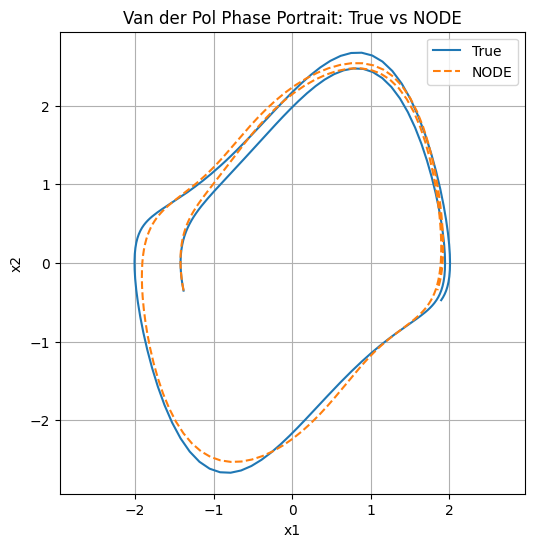

In [13]:
plt.figure(figsize=(6, 6))
plt.plot(true_x_cpu[0, :, 0].numpy(), true_x_cpu[0, :, 1].numpy(), label="True")
plt.plot(pred_x_cpu[0, :, 0].numpy(), pred_x_cpu[0, :, 1].numpy(), "--", label="NODE")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Van der Pol Phase Portrait: True vs NODE")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

In [14]:
test_x = torch.tensor([
    [0.0, 0.0],
    [1.0, 0.0],
    [0.0, 1.0],
    [-1.0, 0.0],
    [2.0, 1.0],
    [-2.0, -1.0],
], device=device)

mu = dataset.mu

with torch.no_grad():
    learned_dxdt = func(test_x)

true_dxdt = true_vdp_dynamics(test_x, mu=mu)

print("x = [x1, x2] | NODE dx/dt | True dx/dt")
for i in range(test_x.shape[0]):
    print(
        test_x[i].cpu().numpy(),
        " | ",
        learned_dxdt[i].cpu().numpy(),
        " | ",
        true_dxdt[i].cpu().numpy()
    )

x = [x1, x2] | NODE dx/dt | True dx/dt
[0. 0.]  |  [0.07435474 0.13452879]  |  [0. 0.]
[1. 0.]  |  [ 0.22923109 -1.0319977 ]  |  [ 0. -1.]
[0. 1.]  |  [1.0581949 2.0290673]  |  [1. 1.]
[-1.  0.]  |  [-0.19092885  1.0762944 ]  |  [0. 1.]
[2. 1.]  |  [ 0.5287591 -4.0021253]  |  [ 1. -5.]
[-2. -1.]  |  [-0.6174543  3.9722636]  |  [-1.  5.]


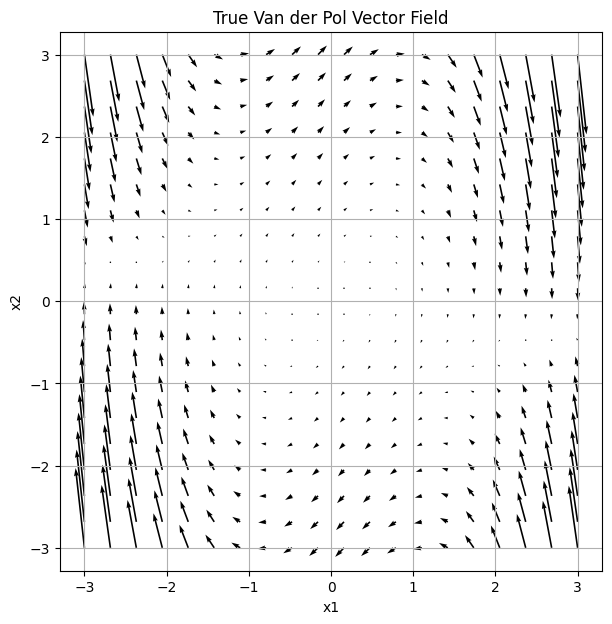

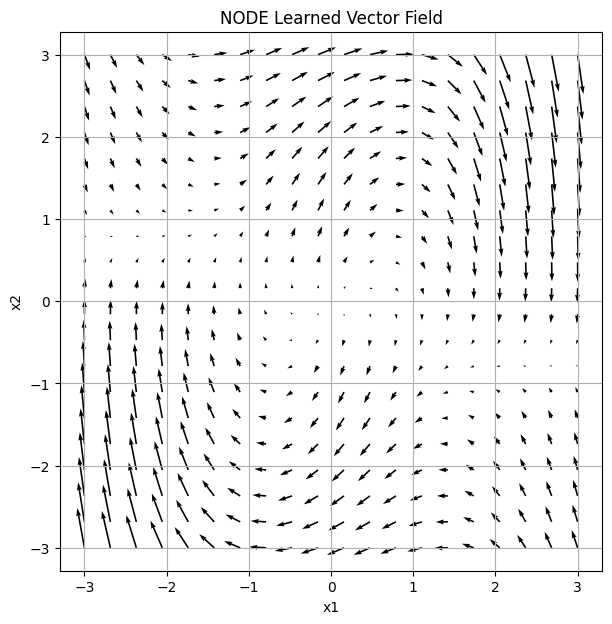

In [ ]:
# Visualize vector field learned by NODE vs true Van der Pol dynamics
x1_vals = torch.linspace(-3, 3, 20)
x2_vals = torch.linspace(-3, 3, 20)

X1, X2 = torch.meshgrid(x1_vals, x2_vals, indexing="ij")

grid = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=1).to(device)

with torch.no_grad():
    true_vec = true_vdp_dynamics(grid, mu=dataset.mu).cpu()
    node_vec = func(grid).cpu()

grid_cpu = grid.cpu()

plt.figure(figsize=(7, 7))
plt.quiver(
    grid_cpu[:, 0].numpy(),
    grid_cpu[:, 1].numpy(),
    true_vec[:, 0].numpy(),
    true_vec[:, 1].numpy()
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("True Van der Pol Vector Field")
plt.grid(True)
plt.axis("equal")
plt.show()

plt.figure(figsize=(7, 7))
plt.quiver(
    grid_cpu[:, 0].numpy(),
    grid_cpu[:, 1].numpy(),
    node_vec[:, 0].numpy(),
    node_vec[:, 1].numpy()
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("NODE Learned Vector Field")
plt.grid(True)
plt.axis("equal")
plt.show()